In [1]:
!pip install ultralytics -q
!pip install pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 28.4 MB/s eta 0:00:00


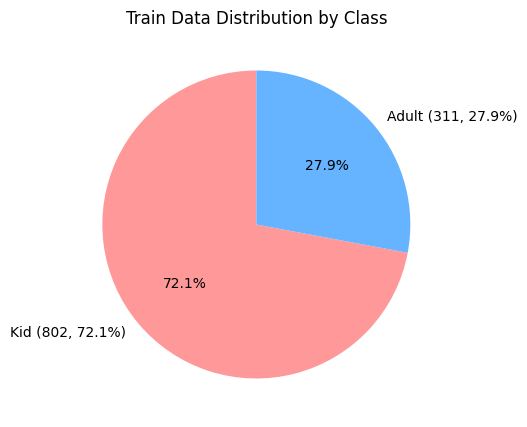

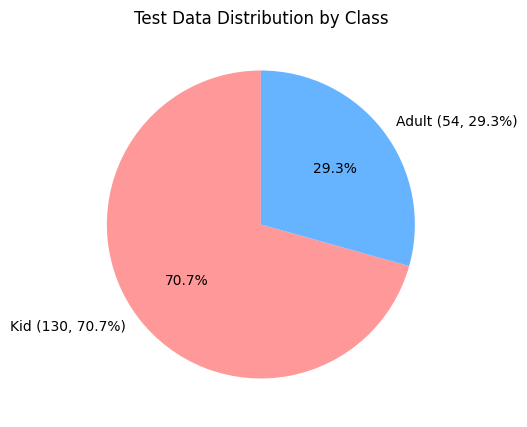

In [2]:
import os
import os
import random
import cv2
import matplotlib.pyplot as plt
import yaml

class data_visualization:
    def __init__(self,main_data_path,dataset_path,data1_yaml):
        self.dataset_path=dataset_path
        self.data1_yaml=data1_yaml
        self.main_data_path=main_data_path
        self.train_labels=None
        self.test_labels=None
        self.unique_labels=None
        self.unique_name=None


        self.get_labels_count()
        self.data_distribution()

    def get_labels_count(self):
        self.train_labels =[]
        self.test_labels=[]
    
        for folder_name in os.listdir(self.dataset_path):
            
            if folder_name.endswith('.cache'):
                pass
            else:
                folder_path = os.path.join(dataset_path,folder_name)
             
                # Loop through all .txt files in the dataset folder
                for file_name in os.listdir(folder_path):
                    if file_name.endswith('.txt'):
                        file_path = os.path.join(folder_path, file_name)
                        with open(file_path, 'r') as file:
                            for line in file:
                                # Extract the class label (first number in the line)
                                class_label = line.split()[0]
                                if folder_name=="train":
                                    self.train_labels.append(class_label)
                                else:
                                    self.test_labels.append(class_label)


        self.unique_labels=list(set(self.train_labels))
        return self.train_labels,self.test_labels


    def pie_chart(self,label_counts,class_labels,cate):
        colors = ['#ff9999', '#66b3ff', '#99ff99']  # Adjust colors as needed
        
        # Calculate percentages for the labels
        total = sum(label_counts)
        percentages = [count / total * 100 for count in label_counts]
        
        # Create a pie chart
        plt.figure(figsize=(5, 5))
        plt.pie(
            label_counts,
            labels=[
                f"{label} ({count}, {percentage:.1f}%)"
                for label, count, percentage in zip(class_labels, label_counts, percentages)
            ],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90
        )
        
        plt.title(f'{cate} Data Distribution by Class')
        plt.show()
        print("\n")


    def data_distribution(self):
        with open(self.data1_yaml, 'r') as file:
            data = yaml.safe_load(file)

        classes=data["names"]
        self.unique_name=list(classes.values())

        
        # Example dataset
        class_labels = []  # Replace with your actual labels
        train_label_counts = []  # Replace with counts of each label in your dataset
        test_label_counts=[]


        for class_label_key in classes.keys():
            class_labels.append(classes[class_label_key])
            if self.train_labels is not None:
                train_label_counts.append(self.train_labels.count(str(class_label_key)))
        
            if self.test_labels is not None:
                test_label_counts.append(self.test_labels.count(str(class_label_key)))
                
        if train_label_counts is not None:
            self.pie_chart(train_label_counts,class_labels,"Train")

        if test_label_counts is not None:
            self.pie_chart(test_label_counts,class_labels,"Test")


    def plot_random_samples(self,split,num_samples=6):
        class_names=self.unique_name
        
        # Get image paths for the specified split
        images_dir = os.path.join(self.main_data_path, 'images', split)
        image_paths = [
            os.path.join(images_dir, file_name)
            for file_name in os.listdir(images_dir)
            if file_name.endswith('.jpg') or file_name.endswith('.png')
        ]
        
        # Randomly sample images
        random_samples = random.sample(image_paths, num_samples)
        
        # Create a 3x2 grid to display the images
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        axes = axes.ravel()  # Flatten axes for easy iteration
    
        for idx, img_path in enumerate(random_samples):
            # Load the image
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            
            # Get corresponding annotation file path in the labels folder
            annotation_path = img_path.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt')
            
            if os.path.exists(annotation_path):
                with open(annotation_path, 'r') as file:
                    annotations = file.readlines()
                
                # Draw bounding boxes from YOLO annotations
                h, w, _ = image.shape
                for annotation in annotations:
                    class_id, x_center, y_center, width, height = map(float, annotation.split())
                    x_center, y_center, width, height = (
                        x_center * w, y_center * h, width * w, height * h
                    )
                    x1, y1 = int(x_center - width / 2), int(y_center - height / 2)
                    x2, y2 = int(x_center + width / 2), int(y_center + height / 2)
                    
                    # Draw the bounding box
                    color = (255, 0, 0)  # Red color for bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
                    
                    # Add class name
                    class_name = class_names[int(class_id)] if int(class_id) < len(class_names) else f"Class {int(class_id)}"
                    cv2.putText(image, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,2, color,4)
            
            # Plot the image in the grid
            axes[idx].imshow(image)
            axes[idx].axis('off')  # Turn off axis
            axes[idx].set_title(f"{split.capitalize()} Sample {idx + 1}")
        
        # Hide any unused subplots
        for i in range(len(random_samples), len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
dataset_path="/kaggle/input/kids-and-adults-detection/children_and_adults/labels"
data1_yaml="/kaggle/input/kids-and-adults-detection/children_and_adults/data1.yaml"
main_data_path="/kaggle/input/kids-and-adults-detection/children_and_adults"
obj=data_visualization(main_data_path,dataset_path,data1_yaml)


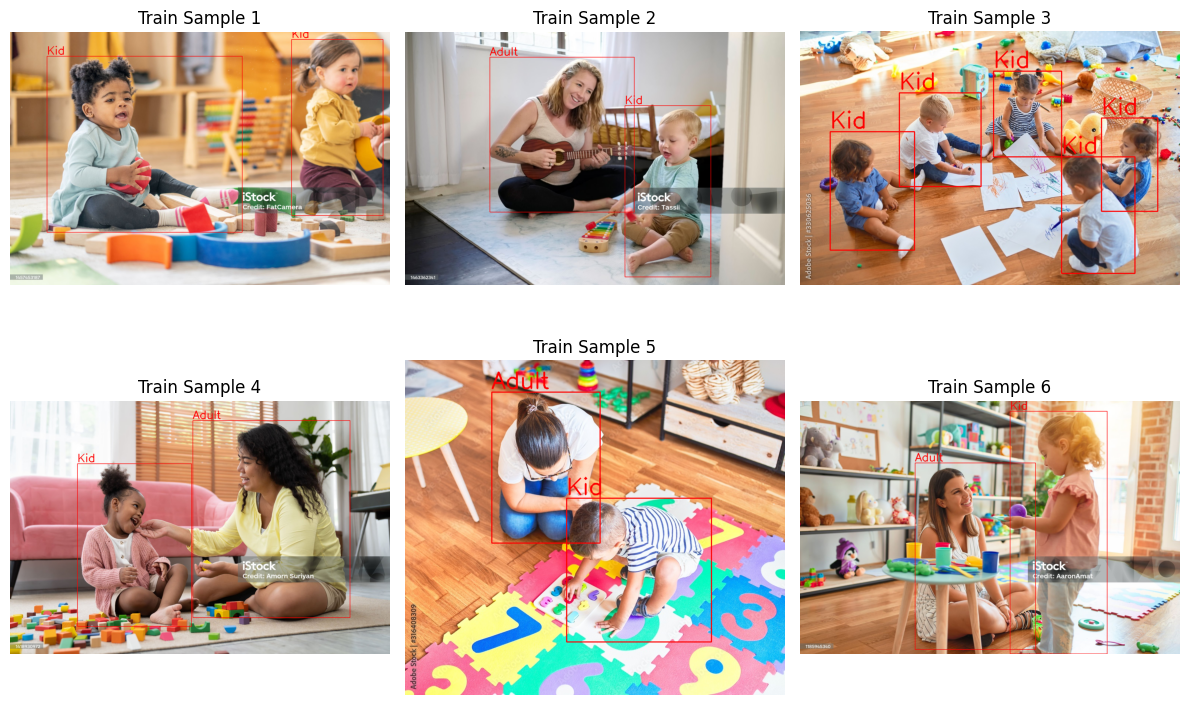

In [3]:
 obj.plot_random_samples(split="train",num_samples=6)

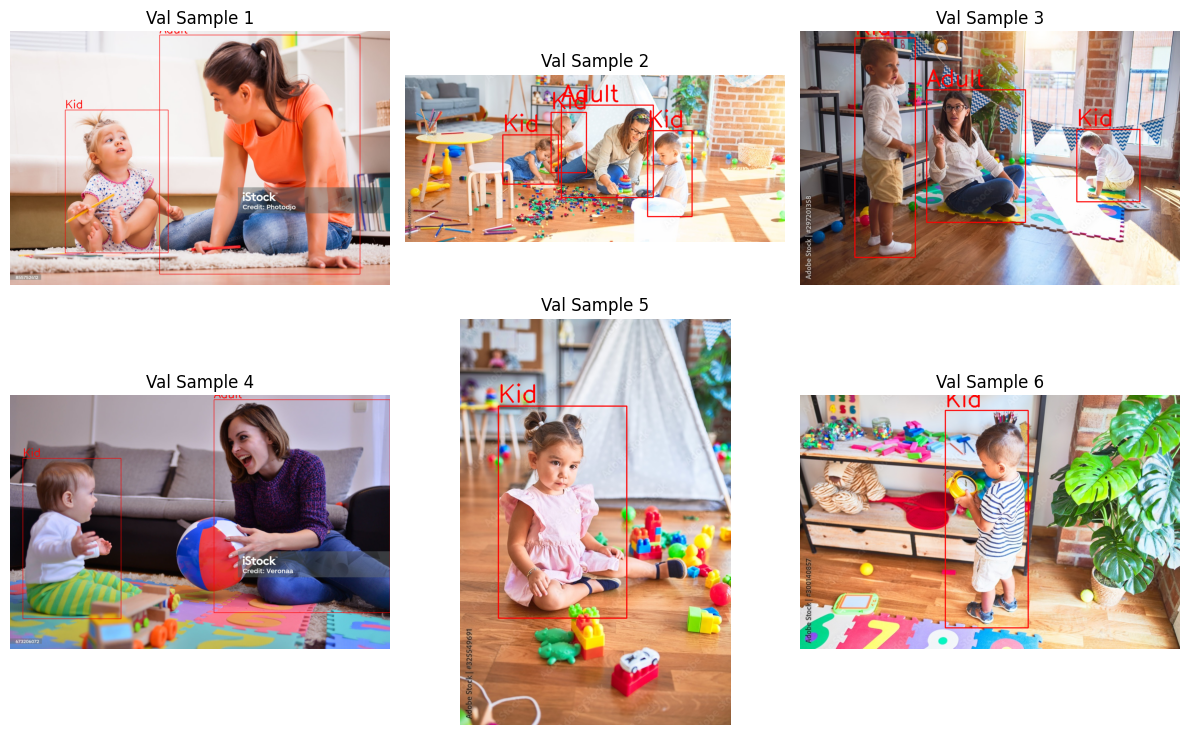

In [4]:
obj.plot_random_samples(split="val",num_samples=6)

In [5]:
import yaml

file_path = '/kaggle/input/kids-and-adults-detection/children_and_adults/data1.yaml'

with open(file_path, 'r') as file:
    data = yaml.safe_load(file)

print(data)


classes=data["names"]
print("classes Name :",classes)

{'path': '/content/drive/MyDrive/KidzCare/data0', 'train': 'images/train', 'val': 'images/val', 'nc': 2, 'names': {0: 'Kid', 1: 'Adult'}}
classes Name : {0: 'Kid', 1: 'Adult'}


In [6]:

%%writefile /kaggle/working/kidsandAdults_yolo_config.yaml

path: '/kaggle/input/kids-and-adults-detection/children_and_adults' # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val  # val images (relative to 'path')

names:
  0: "Kid"
  1: "Adult"

Writing /kaggle/working/kidsandAdults_yolo_config.yaml


In [7]:
pip install ultralytics --upgrade


Note: you may need to restart the kernel to use updated packages.


In [8]:

### 4. Train model ###

import os 
from ultralytics import YOLO


# Load a model
model = YOLO("yolo11s.pt")  # load pre trained mode


# Use the model
results = model.train(data="/kaggle/working/kidsandAdults_yolo_config.yaml",
                      epochs=25,imgsz=640,device=0) 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 18.4M/18.4M [00:00<00:00, 344MB/s]


Ultralytics 8.3.78 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/kaggle/working/kidsandAdults_yolo_config.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

100%|██████████| 755k/755k [00:00<00:00, 45.8MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

...


25 epochs completed in 0.076 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 19.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.78 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.14it/s]


                   all         80        184      0.911      0.938      0.981      0.734
                   Kid         80        130      0.967      0.913      0.984      0.707
                 Adult         54         54      0.856      0.963      0.978      0.761


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 4.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/train


Prediction 1 results 

0: 384x640 2 Kids, 1 Adult, 47.1ms
Speed: 1.6ms preprocess, 47.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
[[15.558252334594727, 5.1104302406311035, 111.68315887451172, 166.37310791015625, 0.7628745436668396, 1.0], [119.83694458007812, 72.35079956054688, 175.43170166015625, 167.57199096679688, 0.718884289264679, 0.0], [175.17581176757812, 17.171628952026367, 239.2501983642578, 167.08953857421875, 0.6240681409835815, 0.0]]


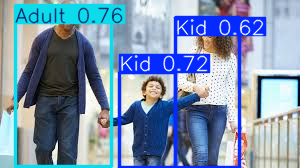



Prediction 2 results 

0: 448x640 1 Kid, 1 Adult, 47.4ms
Speed: 2.1ms preprocess, 47.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
[[357.2431945800781, 11.156997680664062, 799.024169921875, 434.4173583984375, 0.8044390678405762, 1.0], [54.207725524902344, 98.51081848144531, 425.74591064453125, 515.5675659179688, 0.7721349000930786, 0.0]]


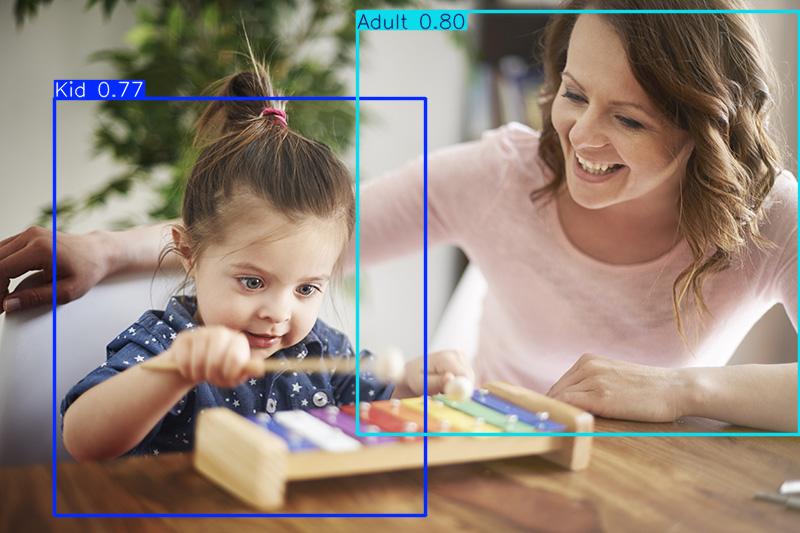



Prediction 3 results 

0: 448x640 1 Kid, 1 Adult, 9.3ms
Speed: 2.0ms preprocess, 9.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
[[383.15985107421875, 66.24193572998047, 614.931640625, 344.00537109375, 0.6216422319412231, 0.0], [256.5885009765625, 23.085397720336914, 418.78704833984375, 417.255859375, 0.45716598629951477, 1.0]]


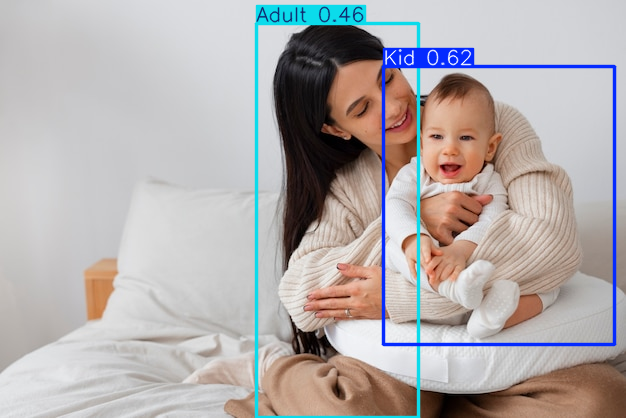



Prediction 4 results 

0: 384x640 1 Kid, 1 Adult, 10.1ms
Speed: 1.6ms preprocess, 10.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
[[313.00244140625, 10.896427154541016, 555.8361206054688, 347.8079833984375, 0.8621342182159424, 1.0], [85.84825134277344, 95.74545288085938, 303.7361755371094, 350.0, 0.7949540615081787, 0.0]]


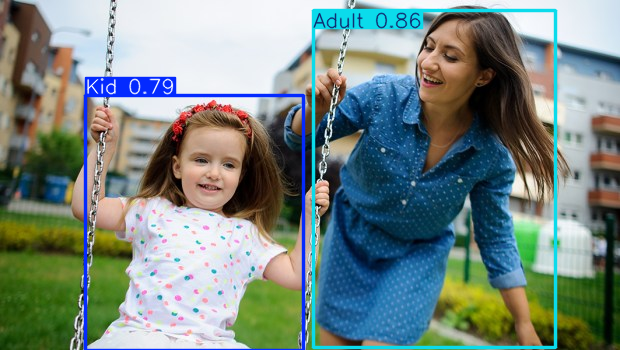

In [9]:
urls= [
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ09q9-SnHjARL2_h4WNFz9m_pFT346kN395w&s",
    "https://www.ctbehavioralhealth.com/wp-content/uploads/2017/10/child-adult-evaluation.jpg",
    "https://img.freepik.com/free-photo/front-view-mother-holding-newborn-baby_23-2150227213.jpg",
    "https://wp.en.aleteia.org/wp-content/uploads/sites/2/2018/06/web3-child-swing-mother-fun-smile-laugh-shutterstock.jpg?resize=620,350&q=75"
]

for i,url in  enumerate(urls):
    print(f"Prediction {i+1} results ")
    # Predict results
    results = model([url])  # return a generator of Results objects

    # Process results generator
    for result in results:
        predict_out = result.boxes.data.tolist()
        print(predict_out)  # Boxes object for bounding box outputs
        result.show()  # display to screen
        result.save(filename="result.jpg")
        print("\n")